# Modelo - EfficientNetV2M

Juan Muelledes Mateos - Trabajo final de Modelado Computacional, Simulacion y Optimización

## 1. Importamos las librerias necesarias

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn
from sklearn.metrics import classification_report
from tensorflow.keras.applications import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as base_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, auc
from sklearn.utils.multiclass import unique_labels
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import itertools
from google.colab import drive

## 2. Cargamos las imagenes y las etiquetas

In [2]:
drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/Archivos Modelado/data.npy')
labels = np.load('/content/drive/MyDrive/Archivos Modelado/labels.npy')

Mounted at /content/drive


In [3]:
def random_rotation(img, angle_range=20):
    angle = np.random.uniform(-angle_range, angle_range)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          borderMode=cv2.BORDER_REFLECT_101)
def random_brightness_contrast(img):
    alpha = np.random.uniform(0.8, 1.2)  # contraste
    beta = np.random.uniform(-25, 25)    # brillo
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def add_gaussian_noise(img):
    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def random_zoom(img, zoom_range=(0.9, 1.1)):
    h, w = img.shape[:2]
    scale = np.random.uniform(*zoom_range)

    new_h, new_w = int(h*scale), int(w*scale)
    resized = cv2.resize(img, (new_w, new_h))

    if scale > 1:
        startx = (new_w - w)//2
        starty = (new_h - h)//2
        return resized[starty:starty+h, startx:startx+w]
    else:
        pad_h = (h - new_h)//2
        pad_w = (w - new_w)//2
        return cv2.copyMakeBorder(
            resized,
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_REFLECT_101
        )
def random_blur(img):
    k = np.random.choice([3,5])
    return cv2.GaussianBlur(img, (k,k), 0)

In [4]:
def produce_new_img_strong(img):

    augmented = []

    augmented.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_180))
    augmented.append(cv2.flip(img, 0))
    augmented.append(cv2.flip(img, 1))
    augmented.append(random_rotation(img))
    augmented.append(random_brightness_contrast(img))
    augmented.append(add_gaussian_noise(img))
    augmented.append(random_zoom(img))
    augmented.append(random_blur(img))

    return augmented

In [5]:
import cv2
from cv2 import imread, resize

def apply_augmentation_to_minority_classes(X_train, y_train_one_hot):

    augmented_images = []
    augmented_labels = []
    y_train_indices = np.argmax(y_train_one_hot, axis=1)
    for img, label_idx in zip(X_train, y_train_indices):
        augmented_images.append(img)
        augmented_labels.append(label_idx)
        if label_idx != 5 and label_idx != 2 and label_idx != 4:  # Después de ordenar, 5 es NV, la clase matyoritaria
            new_imgs = produce_new_img_strong(img)
            for new_img in new_imgs:
                augmented_images.append(new_img)
                augmented_labels.append(label_idx)

    augmented_labels_one_hot = to_categorical(augmented_labels, num_classes=7)
    return np.array(augmented_images), augmented_labels_one_hot

In [6]:
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.1, stratify=labels, random_state=42
)
train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, train_labels, test_size=0.111, stratify=train_labels, random_state=42
)

In [7]:
train_data, train_labels = apply_augmentation_to_minority_classes(train_data, train_labels)

print("Rango de valores en train_data:", train_data.min(), train_data.max())

train_data = (train_data / 127.5) - 1.0
val_data = (val_data / 127.5) - 1.0
test_data = (test_data / 127.5) - 1.0

print("Rango de valores en train_data:", train_data.min(), train_data.max())

Rango de valores en train_data: 0 255
Rango de valores en train_data: -1.0 1.0


## 3. Dividimos los datos a conjuntos de entrenamiento, validación y test

In [8]:
print("train_data shape:", train_data.shape)
print("train_labels shape:", train_labels.shape)
print("val_data shape:", val_data.shape)
print("val_labels shape:", val_labels.shape)
print("test_data shape:", test_data.shape)
print("test_labels shape:", test_labels.shape)

train_data shape: (16792, 224, 224, 3)
train_labels shape: (16792, 7)
val_data shape: (1001, 224, 224, 3)
val_labels shape: (1001, 7)
test_data shape: (1002, 224, 224, 3)
test_labels shape: (1002, 7)


In [9]:
class_names_mapping = {
    0: "AKIEC",
    1: "BCC",
    2: "BKL",
    3: "DF",
    4: "MEL",
    5: "NV",
    6: "VASC"
}

num_classes = train_labels.shape[1]
class_counts_train = np.sum(train_labels, axis=0)
class_counts_val = np.sum(val_labels, axis=0)
class_counts_test = np.sum(test_labels, axis=0)

class_counts_mapping = {}
for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name] = {'Train': class_counts_train[index]}

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Validation'] = class_counts_val[index]

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Test'] = class_counts_test[index]

for class_name, counts in class_counts_mapping.items():
    print(class_name)
    for set_name, count in counts.items():
        print(f" - {set_name}: {count}")

y_train_integers = np.argmax(train_labels, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_dict = {i: np.sqrt(w) for i, w in class_weight_dict.items()}

print("\n Pesos para cada clase para paliar desbalance:")
for cls, weight in class_weight_dict.items():
    print(f"Class {class_names_mapping[cls]}: {weight:.4f}")

AKIEC
 - Train: 2871.0
 - Validation: 33.0
 - Test: 33.0
BCC
 - Train: 4532.0
 - Validation: 51.0
 - Test: 51.0
BKL
 - Train: 879.0
 - Validation: 110.0
 - Test: 110.0
DF
 - Train: 1001.0
 - Validation: 12.0
 - Test: 12.0
MEL
 - Train: 891.0
 - Validation: 111.0
 - Test: 111.0
NV
 - Train: 5364.0
 - Validation: 670.0
 - Test: 671.0
VASC
 - Train: 1254.0
 - Validation: 14.0
 - Test: 14.0

 Pesos para cada clase para paliar desbalance:
Class AKIEC: 0.9141
Class BCC: 0.7275
Class BKL: 1.6520
Class DF: 1.5481
Class MEL: 1.6408
Class NV: 0.6687
Class VASC: 1.3831


## 4. Definimos los elementos necesarios para el entrenamiento

### 4.1 Generador de datos aumentados

In [10]:
batch_size = 16

alpha_list = [class_weight_dict[i] for i in range(num_classes)]  # ya es lista de floats

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [11]:
class MixupSequence(tf.keras.utils.Sequence):
    def __init__(self, x, y, batch_size, datagen, alpha=0.2, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.datagen = datagen
        self.alpha = alpha
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.x) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.x))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_x = self.x[batch_indices].copy()
        batch_y = self.y[batch_indices].copy()

        # Aplicar transformaciones aleatorias a cada imagen
        for i in range(len(batch_x)):
            batch_x[i] = self.datagen.random_transform(batch_x[i])

        # Mezclar con MixUp
        lam = np.random.beta(self.alpha, self.alpha)
        idx_perm = np.random.permutation(len(batch_x))
        mixed_x = lam * batch_x + (1 - lam) * batch_x[idx_perm]
        mixed_y = lam * batch_y + (1 - lam) * batch_y[idx_perm]
        return mixed_x, mixed_y

train_gen = MixupSequence(train_data, train_labels,
                          batch_size=batch_size,
                          datagen=datagen,
                          alpha=0.2)

### 4.2 Funciones de Callback

In [12]:
lr_reduce = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.5, patience = 5,mode='max', min_lr = 1e-5,verbose = 1)
saved_model = '/content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5'
model_chkpt = ModelCheckpoint(saved_model ,save_best_only = True, monitor = 'val_accuracy',verbose = 1)
early_stop = EarlyStopping(monitor = 'val_accuracy', patience = 10, mode='max', verbose = 1)

callback_list = [model_chkpt, lr_reduce, early_stop]

### 4.3 Modelo EfficientNetV2M

In [13]:
base_model = EfficientNetV2M(weights='imagenet',
                        include_top=False,
                        input_shape=(224, 224, 3))

214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


### 4.4 Modificación de la red EfficientNetV2M y compilación

In [14]:
from keras.losses import CategoricalFocalCrossentropy

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

loss_fn = CategoricalFocalCrossentropy(alpha=alpha_list, gamma=2.0)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=loss_fn,
              metrics=['accuracy'])

## 5. Entrenamos el modelo

In [15]:
epochs = 50
batch_size = 16

In [16]:
history = model.fit(train_gen,
                    validation_data=(val_data, val_labels),
                    epochs=epochs,
                    callbacks=callback_list)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.5664 - loss: 0.8533
Epoch 1: val_accuracy improved from None to 0.76523, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 612s 363ms/step - accuracy: 0.6682 - loss: 0.6874 - val_accuracy: 0.7652 - val_loss: 0.4487 - learning_rate: 1.0000e-04
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7725 - loss: 0.5072
Epoch 2: val_accuracy improved from 0.76523 to 0.79121, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 209ms/step - accuracy: 0.7865 - loss: 0.4861 - val_accuracy: 0.7912 - val_loss: 0.3434 - learning_rate: 1.0000e-04
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.8320 - loss: 0.4122
Epoch 3: val_accuracy did not improve from 0.79121
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 204s 194ms/step - accuracy: 0.8312 - loss: 0.4064 - val_accuracy: 0.7363 - val_loss: 0.7426 - learning_rate: 1.0000e-04
Epoch 4/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8541 - loss: 0.3729
Epoch 4: val_accuracy improved from 0.79121 to 0.81419, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5



Epoch 4: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 208ms/step - accuracy: 0.8515 - loss: 0.3724 - val_accuracy: 0.8142 - val_loss: 0.3426 - learning_rate: 1.0000e-04
Epoch 5/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8694 - loss: 0.3462
Epoch 5: val_accuracy improved from 0.81419 to 0.81918, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5


...


Epoch 23: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 230s 219ms/step - accuracy: 0.9610 - loss: 0.1767 - val_accuracy: 0.8871 - val_loss: 0.2432 - learning_rate: 2.5000e-05
Epoch 24/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9527 - loss: 0.1835
Epoch 24: val_accuracy did not improve from 0.88711
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 204s 194ms/step - accuracy: 0.9546 - loss: 0.1785 - val_accuracy: 0.8871 - val_loss: 0.2877 - learning_rate: 2.5000e-05
Epoch 25/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9612 - loss: 0.1767
Epoch 25: val_accuracy improved from 0.88711 to 0.89411, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5



Epoch 25: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 224s 213ms/step - accuracy: 0.9593 - loss: 0.1764 - val_accuracy: 0.8941 - val_loss: 0.2462 - learning_rate: 2.5000e-05
Epoch 26/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9659 - loss: 0.1510
Epoch 26: val_accuracy did not improve from 0.89411
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 205s 195ms/step - accuracy: 0.9639 - loss: 0.1626 - val_accuracy: 0.8821 - val_loss: 0.2437 - learning_rate: 2.5000e-05
Epoch 27/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9603 - loss: 0.1705
Epoch 27: val_accuracy did not improve from 0.89411
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 213s 203ms/step - accuracy: 0.9635 - loss: 0.1630 - val_accuracy: 0.8931 - val_loss: 0.2862 - learning_rate: 2.5000e-05
Epoch 28/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9639 - loss: 0.1583
Epoch 28: val_accuracy improved from 0.89411 to 0.89610, s


Epoch 28: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 209ms/step - accuracy: 0.9631 - loss: 0.1591 - val_accuracy: 0.8961 - val_loss: 0.2333 - learning_rate: 2.5000e-05
Epoch 29/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9609 - loss: 0.1700
Epoch 29: val_accuracy improved from 0.89610 to 0.90509, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5



Epoch 29: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 216s 205ms/step - accuracy: 0.9617 - loss: 0.1664 - val_accuracy: 0.9051 - val_loss: 0.2741 - learning_rate: 2.5000e-05
Epoch 30/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9613 - loss: 0.1708
Epoch 30: val_accuracy did not improve from 0.90509
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 213s 203ms/step - accuracy: 0.9640 - loss: 0.1639 - val_accuracy: 0.8971 - val_loss: 0.2605 - learning_rate: 2.5000e-05
Epoch 31/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9632 - loss: 0.1637
Epoch 31: val_accuracy did not improve from 0.90509
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 202s 193ms/step - accuracy: 0.9665 - loss: 0.1572 - val_accuracy: 0.9031 - val_loss: 0.2452 - learning_rate: 2.5000e-05
Epoch 32/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9589 - loss: 0.1723
Epoch 32: val_accuracy did not improve from 0.90509
1050/1


Epoch 35: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 208ms/step - accuracy: 0.9650 - loss: 0.1625 - val_accuracy: 0.9131 - val_loss: 0.2622 - learning_rate: 1.2500e-05
Epoch 36/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9672 - loss: 0.1673
Epoch 36: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 209s 198ms/step - accuracy: 0.9614 - loss: 0.1669 - val_accuracy: 0.9071 - val_loss: 0.2550 - learning_rate: 1.2500e-05
Epoch 37/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9579 - loss: 0.1616
Epoch 37: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 203s 194ms/step - accuracy: 0.9601 - loss: 0.1557 - val_accuracy: 0.9001 - val_loss: 0.2735 - learning_rate: 1.2500e-05
Epoch 38/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9649 - loss: 0.1457
Epoch 38: val_accuracy did not improve from 0.91309
1050/1

In [17]:
model.load_weights(saved_model)
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss="categorical_crossentropy",
              metrics=['accuracy'])

fine_lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, mode='max', min_lr=1e-8, verbose=1)
fine_early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=8, verbose=1)
fine_checkpoint = ModelCheckpoint(saved_model.replace('.h5', '_finetuned.h5'), save_best_only=True, monitor='val_accuracy', verbose=1)

fine_callbacks = [fine_checkpoint, fine_lr_reduce, fine_early_stop]

fine_tune_epochs = 15
history_fine = model.fit(datagen.flow(train_data, train_labels, batch_size=batch_size),
                         validation_data=(val_data, val_labels),
                         epochs=fine_tune_epochs,
                         callbacks=fine_callbacks)

Epoch 1/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9974 - loss: 0.1247
Epoch 1: val_accuracy improved from None to 0.91309, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M_finetuned.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/EfficientNetV2M_finetuned.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 326s 226ms/step - accuracy: 0.9977 - loss: 0.0870 - val_accuracy: 0.9131 - val_loss: 0.3471 - learning_rate: 1.0000e-06
Epoch 2/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9979 - loss: 0.0332
Epoch 2: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 168s 159ms/step - accuracy: 0.9981 - loss: 0.0278 - val_accuracy: 0.9121 - val_loss: 0.3948 - learning_rate: 1.0000e-06
Epoch 3/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9973 - loss: 0.0176
Epoch 3: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 167s 159ms/step - accuracy: 0.9979 - loss: 0.0158 - val_accuracy: 0.9131 - val_loss: 0.4377 - learning_rate: 1.0000e-06
Epoch 4/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9983 - loss: 0.0123
Epoch 4: val_accuracy did not improve from 0.91309

Ep

## 6. Evaluamos el modelo

### 6.1 Precisión del conjunto de test

In [18]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 596ms/step - accuracy: 0.9142 - loss: 0.4019
Test Accuracy: 0.9141716361045837


### 6.2 Informe de clasificación del modelo

In [ ]:
predictions = model.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)
report = classification_report(true_labels, predicted_labels)

print("Classification Report:")
print(report)

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 222ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       196
           1       1.00      0.98      0.99       308
           2       0.96      1.00      0.98       660
           3       1.00      1.00      1.00        69
           4       0.94      1.00      0.97       668
           5       1.00      0.92      0.96       671
           6       0.99      1.00      0.99        85

    accuracy                           0.97      2657
   macro avg       0.98      0.98      0.98      2657
weighted avg       0.97      0.97      0.97      2657



### 6.3 Matriz de confusion

In [ ]:
cm = confusion_matrix(true_labels, np.round(predicted_labels))
cm

array([[186,   0,   7,   0,   3,   0,   0],
       [  0, 303,   4,   0,   1,   0,   0],
       [  0,   0, 657,   0,   1,   1,   1],
       [  0,   0,   0,  69,   0,   0,   0],
       [  0,   0,   1,   0, 666,   1,   0],
       [  0,   1,  13,   0,  37, 620,   0],
       [  0,   0,   0,   0,   0,   0,  85]])

Normalized confusion matrix


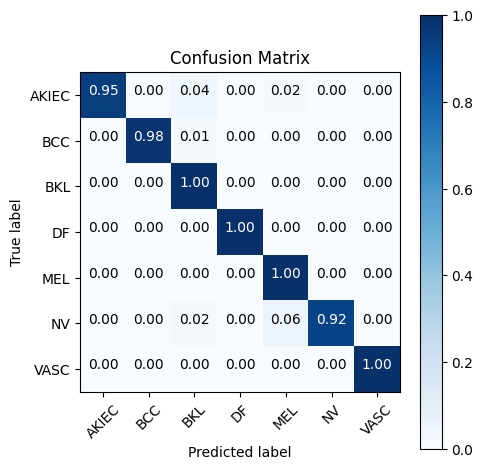

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm_plot_labels = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)

Text(0.5, 1.0, 'Accuracy Curves')

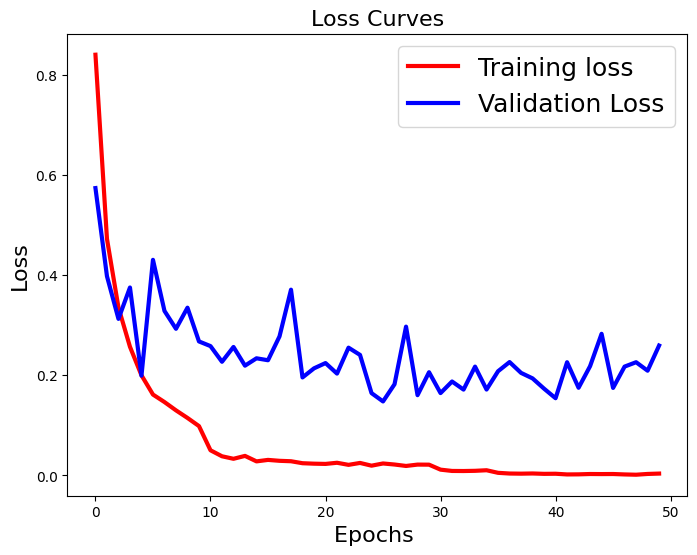

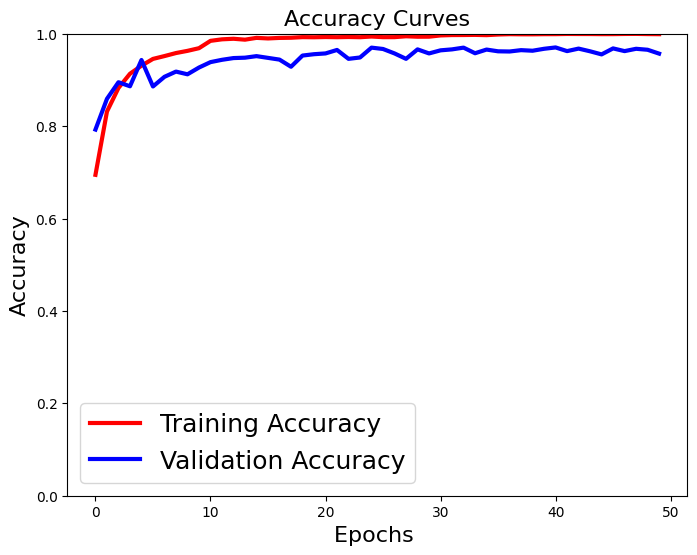

In [ ]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

# Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.ylim(0, 1)
plt.title('Accuracy Curves',fontsize=16)